In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")

print(datadir)

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/whole-brain


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from numba.typed import Dict
from numba.core import types
import pickle

from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, cost_functions

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1


# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

weights = Dict.empty(
        key_type=types.unicode_type,
        value_type=types.float64,
    )

weights["w_2"] = 0.0
weights["w_1"] = 0.0
weights["w_1T"] = 0.0
weights["w_1D"] = 1.0

In [3]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

In [4]:
coords = [[1.6, 0.0], [1.7, 0.1]] #1st: multistable     // 2nd: unistable synchronized

data_0_L1, data_1_L1, data_2_L1 = dict(), dict(), dict()
data_0_L1["coordinates"] = coords[0]
data_1_L1["coordinates"] = coords[0]
data_2_L1["coordinates"] = coords[1]
lng = int(4*1e3)

for d in [data_0_L1, data_1_L1, data_2_L1]:
    d["weights"] = np.zeros((100))
    d["control"] = [None] * len(data_0_L1["weights"])
    d["state"] = [None] * len(data_0_L1["weights"])
    d["init_state"] = None
    d["energy_input"] = np.zeros((len(d["weights"])))
    d["sync_cost"] = np.zeros((len(d["weights"])))
    d["state_uncontrolled"] = np.zeros((N,2,lng))

data_1_L1["weights"] *= -1

In [5]:
def setparams(model):
    model.params.c_excinh = 12  # local E-I coupling
    model.params.signalV = 80.0
    model.params.K_gl = 0.5  # global coupling strength
    model.params.a_exc = 1.  # excitatory gain
    model.params.a_inh = 1.  # inhibitory gain
    model.params.mu_exc = 5.0  # excitatory firing threshold
    model.params.mu_inh = 5.0  # inhibitory firing threshold

def plot_control(c, s, dur, dt, fat=[], filename=None, title=None):
    fig, ax = plt.subplots(2,1, figsize=(32,8), sharex=True)
    time_array = np.arange(0, dur+dt, dt)

    cmax = np.amax(np.abs(c))
    y1lim = [-cmax* 1.1, cmax* 1.1]

    for n in range(N):
        if n in fat:
            ax[0].plot(time_array, s[n,0,:], linewidth=4)
        else:
            ax[0].plot(time_array, s[n,0,:])
        ax[1].plot(time_array, c[n,0,:])

    ax[0].set_xlim(0, dur)

    ax[1].set_ylim(y1lim)

    ax[1].set_xlabel("Time")
    ax[0].set_ylabel("Activity")
    ax[1].set_ylabel("Control")

    plt.subplots_adjust(
                    wspace=0.15,
                    hspace=0.1)
    
    fig.align_ylabels([ax[0]])
    
    if title is not None:
        fig.suptitle(title)

    if filename is not None:
        plt.savefig(filename, bbox_inches='tight', dpi=200)

    plt.show()
    return

def get_results(d, wi, mc):
    d["control"][wi] = mc.control.copy()
    d["state"][wi] = mc.get_xs()
    d["energy_input"][wi] = cost_functions.control_strength_cost(mc.control, weights, dt)
    d["sync_cost"][wi] = (mc.compute_total_cost() - d["energy_input"][wi])/d["weights"][wi]

def dump_data():
    with open(os.path.join(datadir, 'wb_L1_all_2.pickle'), 'wb') as f:
        pickle.dump(data_2_L1, f)

controlmat = np.zeros((N,2))
controlmat[:,0] = 1

costmat = np.zeros((N, 2))
costmat[:,0] = 1.

duration = 400.
target_period = 1

int0 = 0
int1 = None

max_cntrl = 5
pr = np.arange(0,101,1)
dt = 0.1

------------------- seed =  1


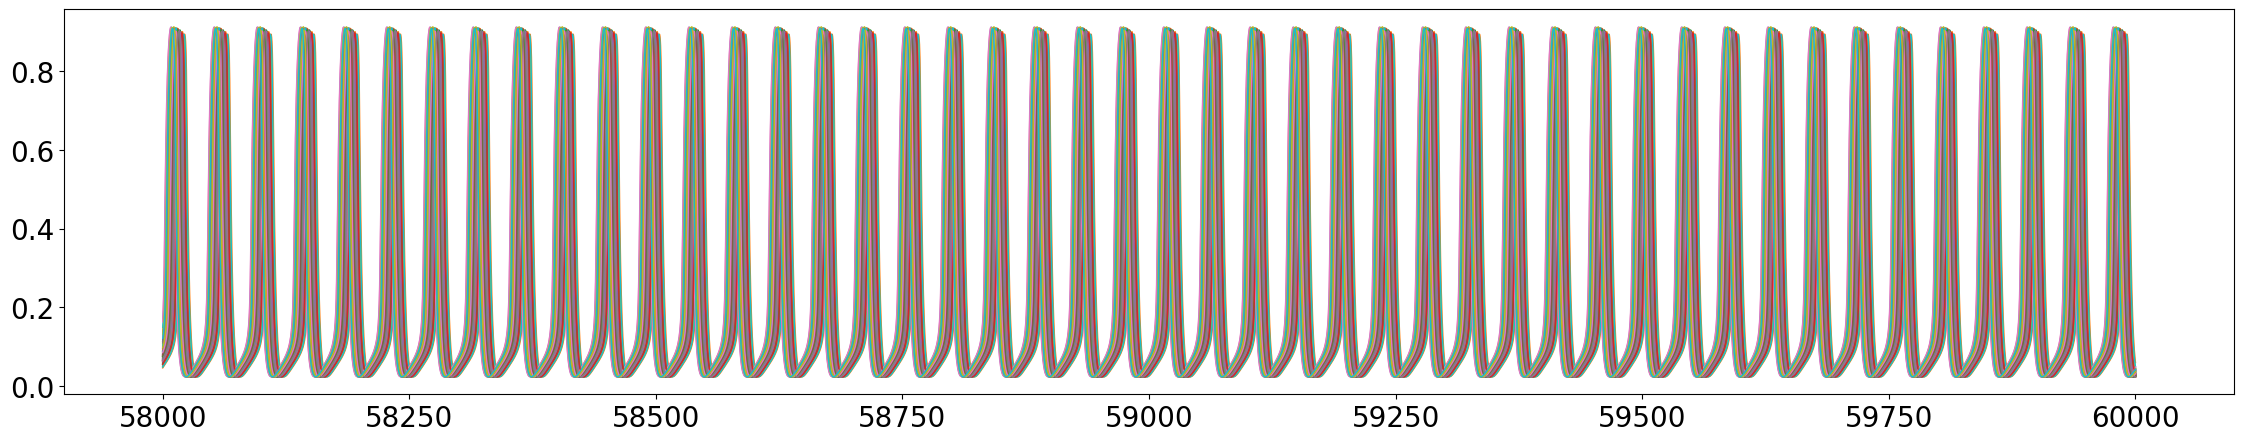

/home/lena/Promotion/neurolib/neurolib/control/optimal_control/cost_functions.py:335: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'getmean_vt'.

For more information visit https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "neurolib/control/optimal_control/cost_functions.py", line 314:
@numba.njit
def getmean_vt(
^

  xmean = getmean_vt(x_sim, interval)
/home/lena/.local/lib/python3.10/site-packages/numba/core/ir_utils.py:2149: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'var_cost'.

For more information visit https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "neurolib/control/optimal_control/cost_functions.py", lin

0.032164549250778954


/home/lena/.local/lib/python3.10/site-packages/numba/core/ir_utils.py:2149: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'cc_cost'.

For more information visit https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "neurolib/control/optimal_control/cost_functions.py", line 414:
@numba.njit
def cc_cost(
^

  warnings.warn(NumbaPendingDeprecationWarning(msg, loc=loc))


-0.6242257109598518
------------------- seed =  25


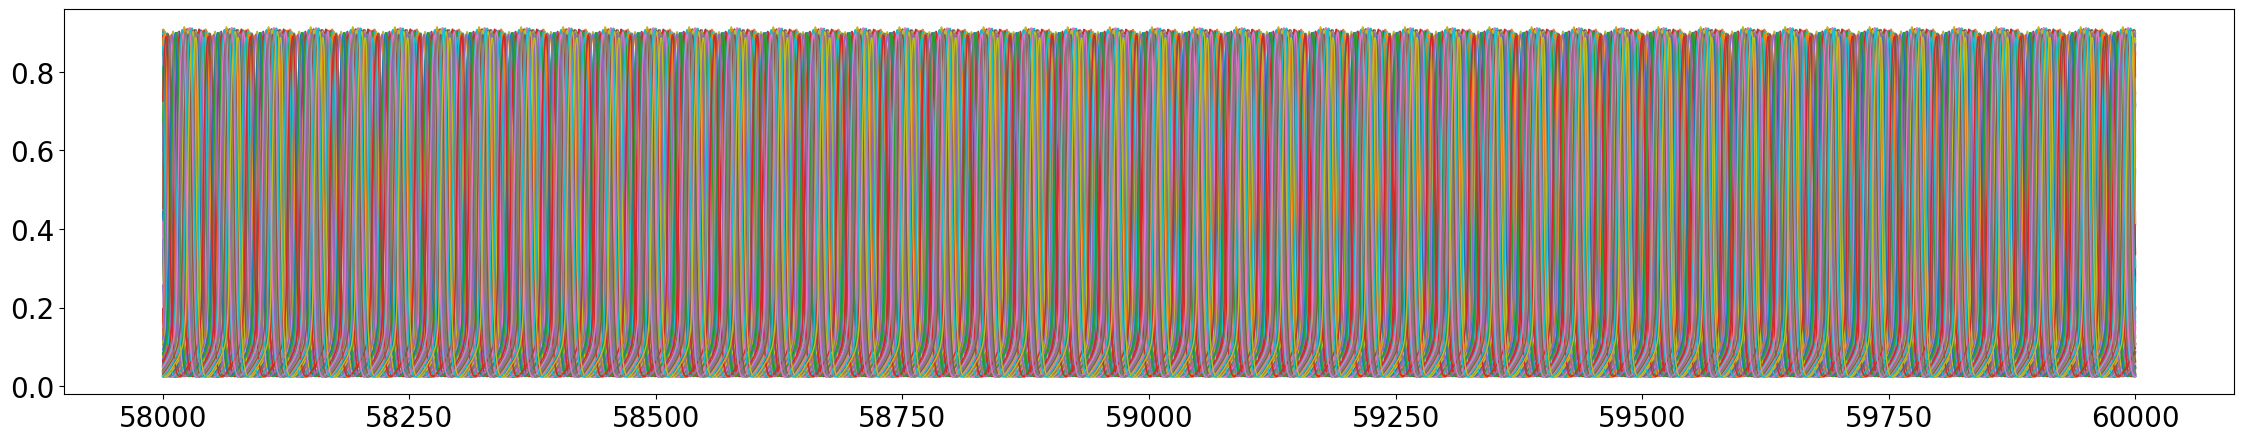

0.08426829728692982
-0.025985539150927384


In [13]:
point = 0
seed = [1, 25]

#for s in np.arange(0,50,1):
for i_s, s in enumerate(seed):

    print("------------------- seed = ", s)

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=s)
    testd = 60.*1e3     # needs to stay 60!!!!!
    dt = model.params.dt
    model.params.duration = testd
    model.params.seed = s
    setparams(model)

    #zero_input = ZeroInput().generate_input(duration=testd+model.params.dt, dt=model.params.dt)
    #input = zero_input.copy()
    #input[0,int(0.*1e3/dt):int(5.*1e3/dt)] = 1.

    #print(model.params.exc_init[0,0])

    model.params.exc_ext_baseline = data_0_L1["coordinates"][0]
    model.params.exc_inh_baseline = data_0_L1["coordinates"][1]

    #model.params.exc_ext = input
    model.run()

    plt.figure(figsize=(28,5))

    for n in range(N):
        plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
    plt.show()

    nmaxdelay = model.getMaxDelay()
    einit = np.zeros((N, nmaxdelay+1))
    iinit = np.zeros((N, nmaxdelay+1))

    state = np.zeros((N,2,lng))

    for n in range(N):
        einit[n,:] = model.exc[n,-nmaxdelay-1:]
        iinit[n,:] = model.inh[n,-nmaxdelay-1:]
        state[n,0,:] = model.exc[n, -lng:]

    if i_s == 0:
        data_0_L1["init_state"] = [einit, iinit]
        data_0_L1["state_uncontrolled"] = state.copy()
    else:
        data_1_L1["init_state"] = [einit, iinit]
        data_1_L1["state_uncontrolled"] = state.copy()

    var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
    print(var_cost_asyn)

    cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
    print(cc_cost)

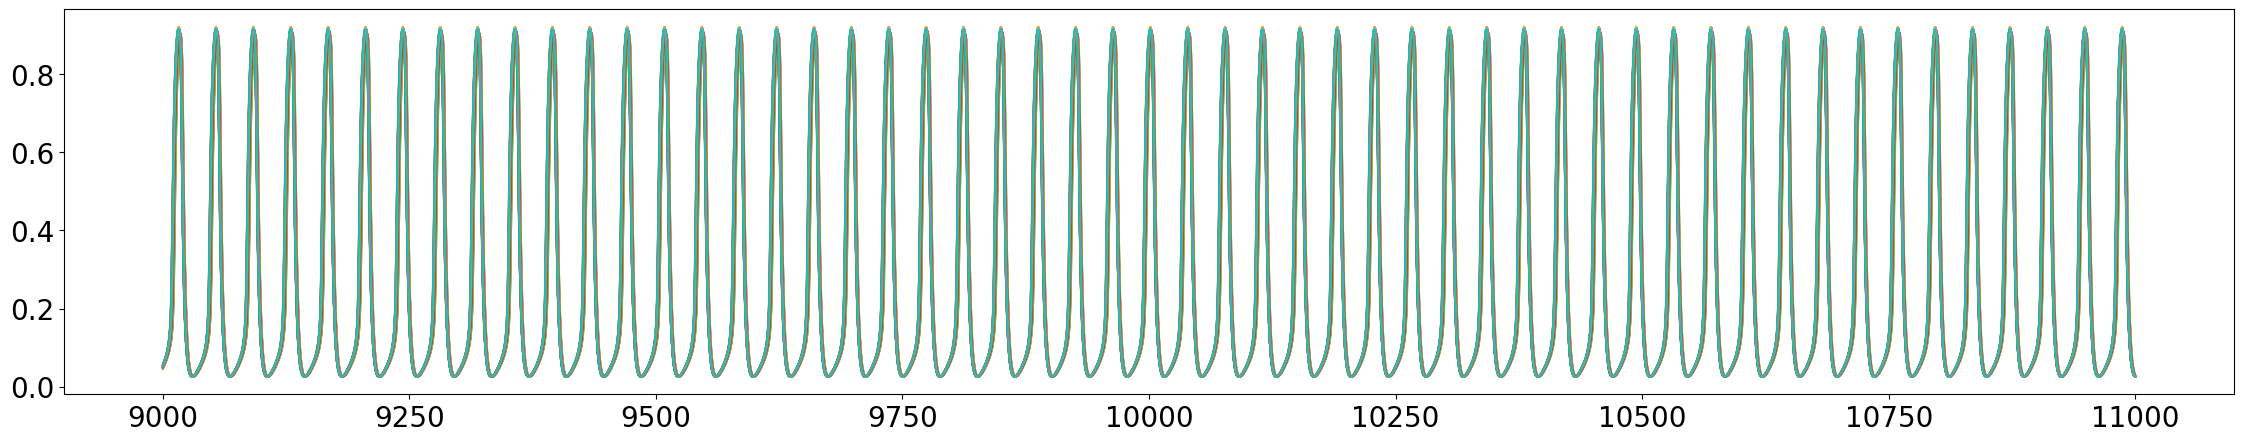

0.002332105821483664
-0.9775374609292389


In [14]:
model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
testd = 11.*1e3   ## needs to stay 11
dt = model.params.dt
model.params.duration = testd
setparams(model)

model.params.exc_ext_baseline = data_2_L1["coordinates"][0]
model.params.exc_inh_baseline = data_2_L1["coordinates"][1]

#model.params.exc_ext = input
model.run()

plt.figure(figsize=(28,5))

for n in range(N):
    plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
plt.show()

nmaxdelay = model.getMaxDelay()
einit = np.zeros((N, nmaxdelay+1))
iinit = np.zeros((N, nmaxdelay+1))

state = np.zeros((N,2,lng))

for n in range(N):
    einit[n,:] = model.exc[n,-nmaxdelay-1:]
    iinit[n,:] = model.inh[n,-nmaxdelay-1:]
    state[n,0,:] = model.exc[n, -lng:]

data_2_L1["init_state"] = [einit, iinit]
data_2_L1["state_uncontrolled"] = state.copy()

var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(var_cost_asyn)

cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(cc_cost)

In [6]:
with open(os.path.join(datadir, 'wb_L1_all_2.pickle'), 'rb') as f:
    data_read = pickle.load(f)

data_2_L1 = data_read

In [17]:
print(data_2_L1["weights"])

[  -20.   -40.   -60.   -80.  -100.  -120.  -140.  -160.  -180.  -200.
  -220.  -240.  -260.  -280.  -300.  -320.  -340.  -360.  -380.  -400.
  -420.  -440.  -460.  -480.  -500.  -520.  -540.  -560.  -580.  -600.
  -620.  -640.  -660.  -680.  -700.  -720.  -740.  -760.  -780.  -800.
  -820.  -840.  -860.  -880.  -900.  -920.  -940.  -960.  -980. -1000.
 -1020. -1040. -1060. -1080. -1100. -1120. -1140. -1160. -1180. -1200.
 -1220. -1240. -1260. -1280. -1300. -1320. -1340. -1360. -1380. -1400.
 -1420. -1440. -1460. -1480. -1500. -1520. -1540. -1560. -1580. -1600.
 -1620. -1640. -1660. -1680. -1700. -1720. -1740. -1760. -1780. -1800.
 -1820. -1840. -1860. -1880. -1900. -1920. -1940. -1960. -1980. -2000.]


In [7]:
data_2_L1["weights"][0] = -20.
for n in range(N-1):
    data_2_L1["weights"][n+1] = data_2_L1["weights"][n] - 20.

In [8]:
def optimize_model(model, step_exp_array, wi, it):
    for k in step_exp_array:
        model.zero_step_encountered = False
        model.step = 10.**(k)
        model.optimize(it)

        get_results(d, wi, model)
        dump_data()

------------------------------------------------------------ wi =  0 -20.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.05940280805385149
Final cost : -0.05940280805385149
Compute control for a deterministic system
Cost in iteration 0: -0.05940280805385149
Cost in iteration 1: -0.05940280805385149
Converged in iteration 1 with cost -0.05940280805385149
Final cost : -0.05940280805385149
Compute control for a deterministic system
Cost in iteration 0: -0.05940280805385149
Cost in iteration 1: -0.05940280805385149
Converged in iteration 1 with cost -0.05940280805385149
Final cost : -0.05940280805385149
Compute control for a deterministic system
Cost in iteration 0: -0.05940280805385149
Cost in iteration 1: -0.05940280805385149
Converged in iteration 1 with cost -0.05940280805385149
Final cost : -0.05940280805385149
Compute control for a deterministic system
Cost in iteration 0: -0.05940280805385149
Cost in iteration 1: -0

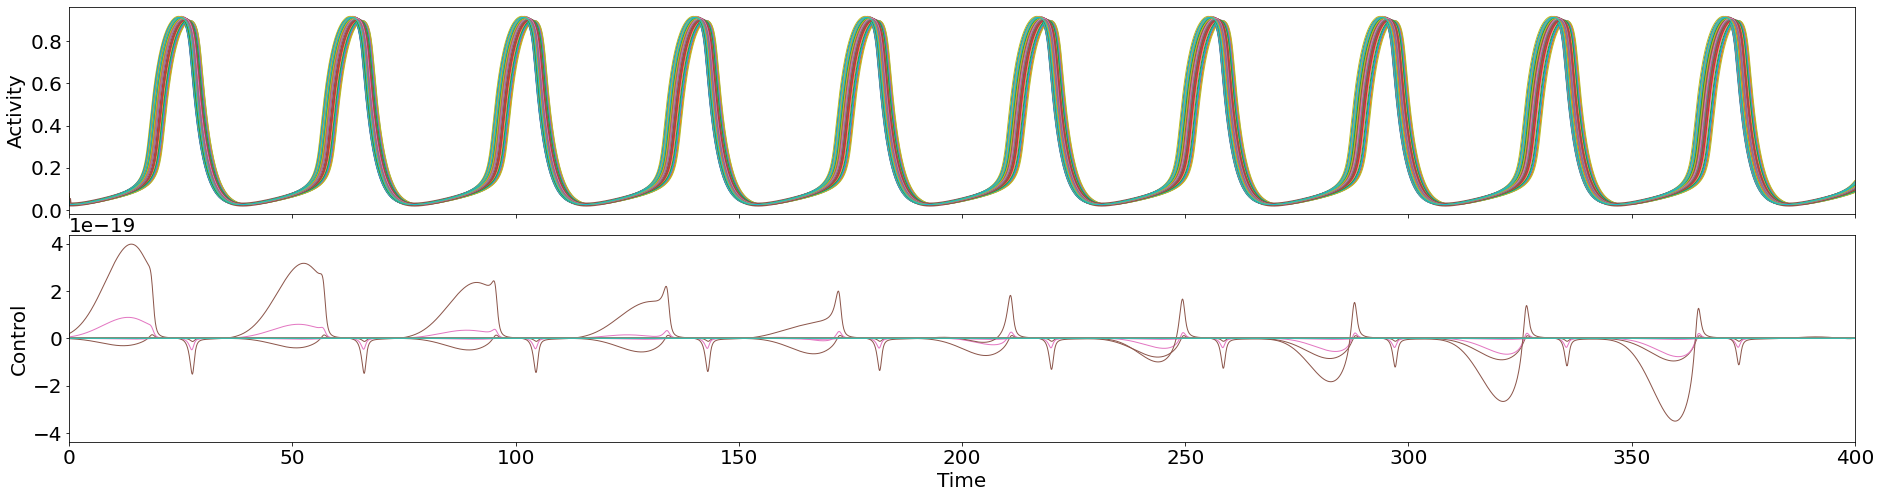

------------------------------------------------------------ wi =  2 -60.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.17820842416155502
Final cost : -0.17820842416155502
Compute control for a deterministic system
Cost in iteration 0: -0.17820842416155502
Cost in iteration 1: -0.17820842416155502
Converged in iteration 1 with cost -0.17820842416155502
Final cost : -0.17820842416155502
Compute control for a deterministic system
Cost in iteration 0: -0.17820842416155502
Cost in iteration 1: -0.17820842416155502
Converged in iteration 1 with cost -0.17820842416155502
Final cost : -0.17820842416155502
Compute control for a deterministic system
Cost in iteration 0: -0.17820842416155502
Cost in iteration 1: -0.17820842416155502
Converged in iteration 1 with cost -0.17820842416155502
Final cost : -0.17820842416155502
Compute control for a deterministic system
Cost in iteration 0: -0.17820842416155502
Cost in iteration 1: -0

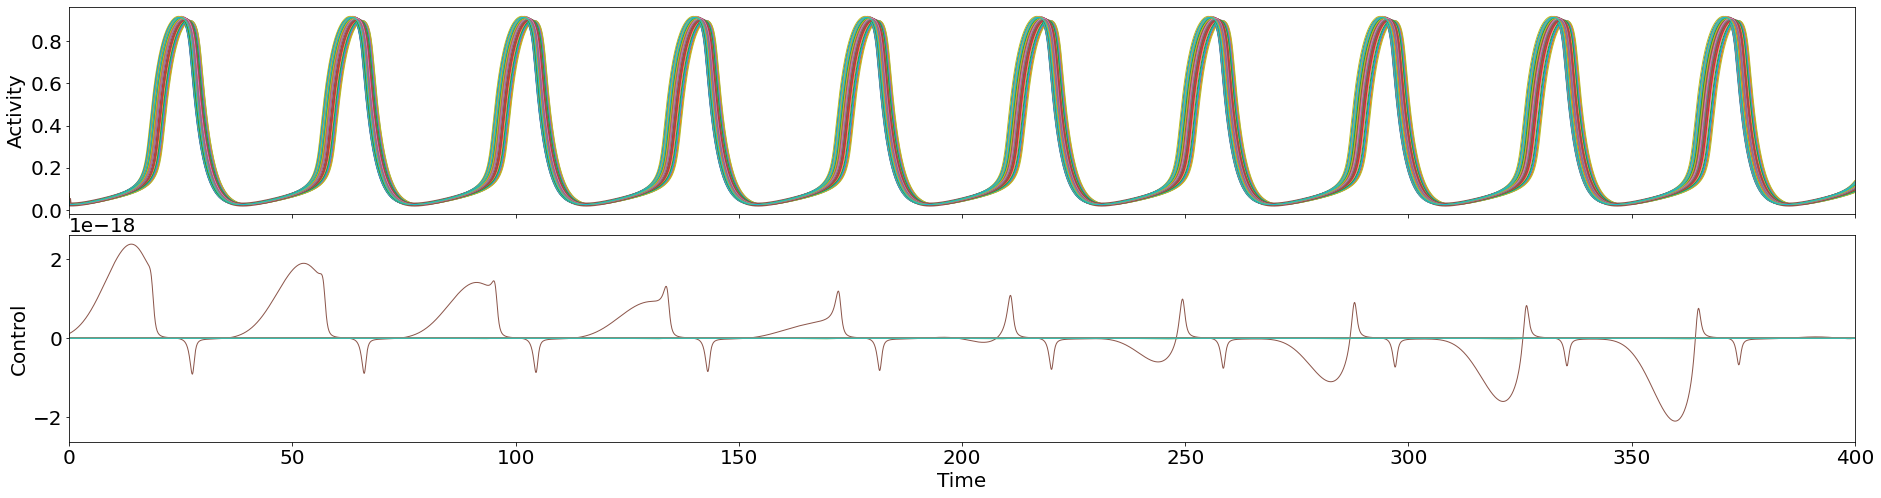

------------------------------------------------------------ wi =  4 -100.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.2970140402692581
Final cost : -0.2970140402692581
Compute control for a deterministic system
Cost in iteration 0: -0.2970140402692581
Cost in iteration 1: -0.2970140402692581
Converged in iteration 1 with cost -0.2970140402692581
Final cost : -0.2970140402692581
Compute control for a deterministic system
Cost in iteration 0: -0.2970140402692581
Cost in iteration 1: -0.2970140402692581
Converged in iteration 1 with cost -0.2970140402692581
Final cost : -0.2970140402692581
Compute control for a deterministic system
Cost in iteration 0: -0.2970140402692581
Cost in iteration 1: -0.2970140402692581
Converged in iteration 1 with cost -0.2970140402692581
Final cost : -0.2970140402692581
Compute control for a deterministic system
Cost in iteration 0: -0.2970140402692581
Cost in iteration 1: -0.2970140402692

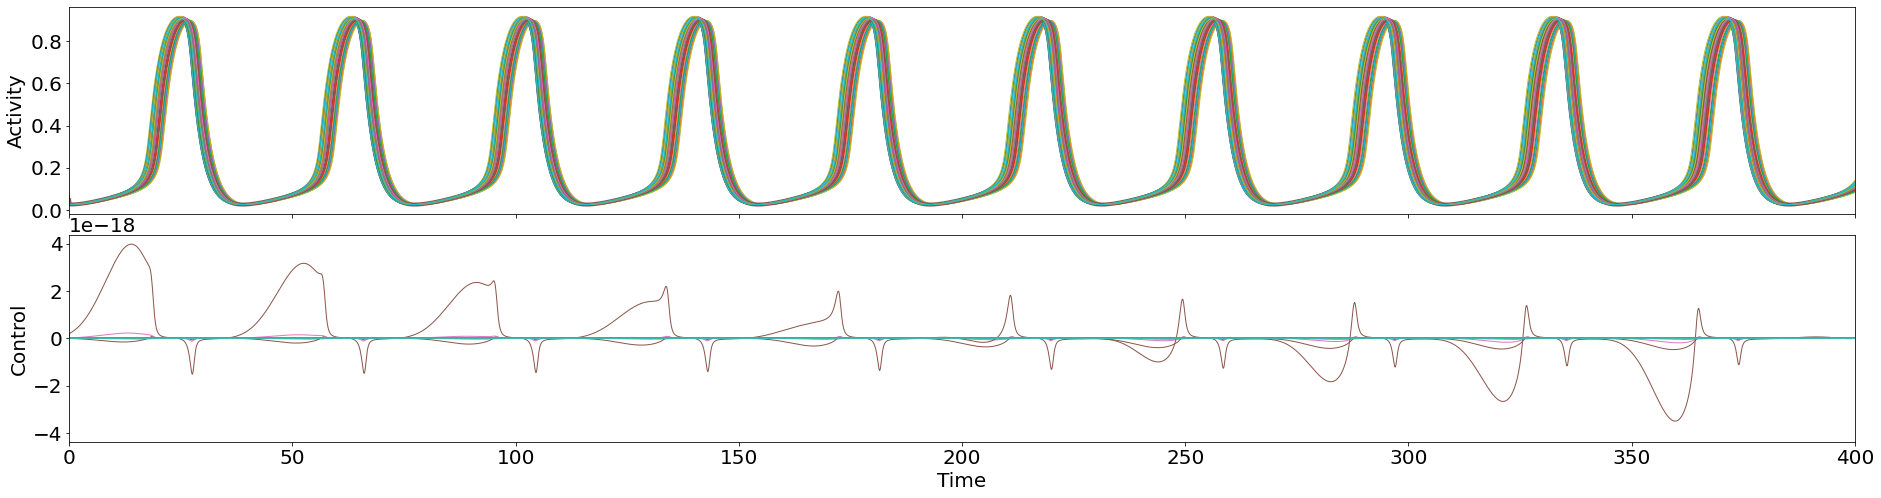

------------------------------------------------------------ wi =  6 -140.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.4158196563769606
Final cost : -0.4158196563769606
Compute control for a deterministic system
Cost in iteration 0: -0.4158196563769606
Cost in iteration 1: -0.4158196563769606
Converged in iteration 1 with cost -0.4158196563769606
Final cost : -0.4158196563769606
Compute control for a deterministic system
Cost in iteration 0: -0.4158196563769606
Cost in iteration 1: -0.4158196563769606
Converged in iteration 1 with cost -0.4158196563769606
Final cost : -0.4158196563769606
Compute control for a deterministic system
Cost in iteration 0: -0.4158196563769606
Cost in iteration 1: -0.4158196563769606
Cost in iteration 2: -0.4158196563769606
Converged in iteration 2 with cost -0.4158196563769606
Final cost : -0.4158196563769606
Compute control for a deterministic system
Cost in iteration 0: -0.4158196563769

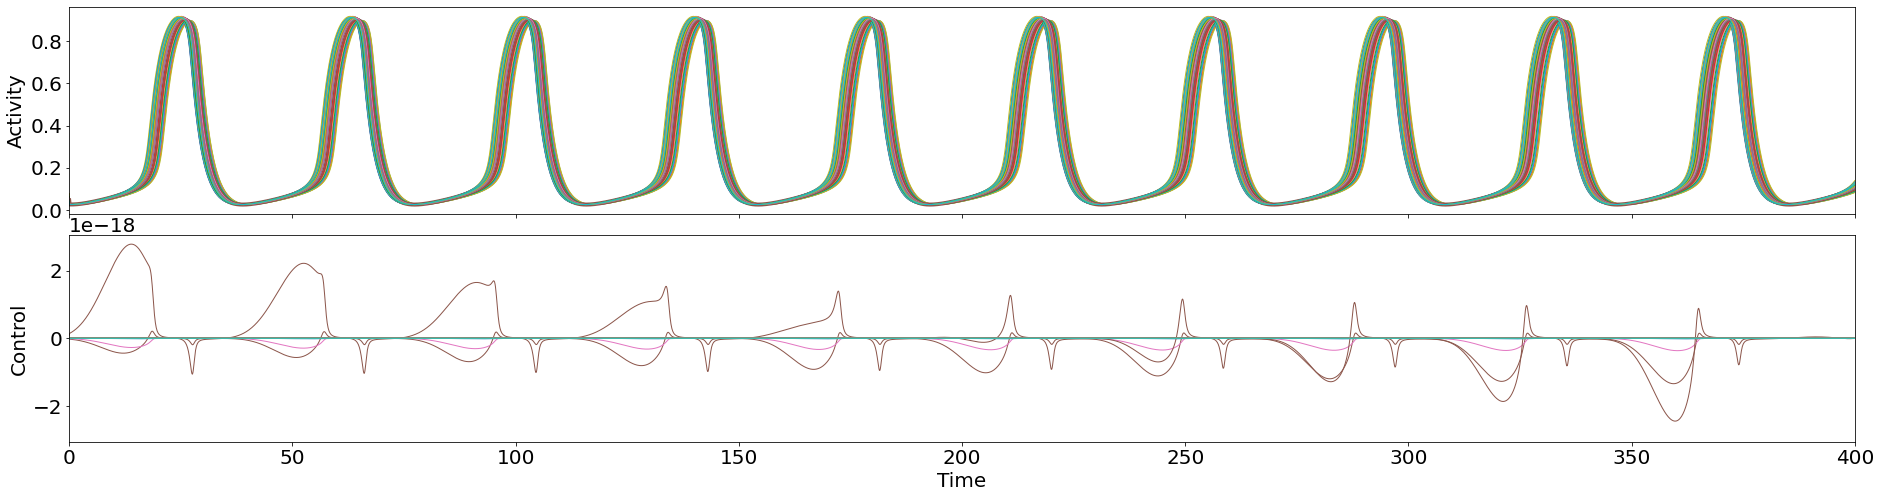

------------------------------------------------------------ wi =  8 -180.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.5346252724846645
Final cost : -0.5346252724846645
Compute control for a deterministic system
Cost in iteration 0: -0.5346252724846645
Cost in iteration 1: -0.5346252724846645
Converged in iteration 1 with cost -0.5346252724846645
Final cost : -0.5346252724846645
Compute control for a deterministic system
Cost in iteration 0: -0.5346252724846645
Cost in iteration 1: -0.5346252724846645
Converged in iteration 1 with cost -0.5346252724846645
Final cost : -0.5346252724846645
Compute control for a deterministic system
Cost in iteration 0: -0.5346252724846645
Cost in iteration 1: -0.5346252724846645
Cost in iteration 2: -0.5346252724846645
Converged in iteration 2 with cost -0.5346252724846645
Final cost : -0.5346252724846645
Compute control for a deterministic system
Cost in iteration 0: -0.5346252724846

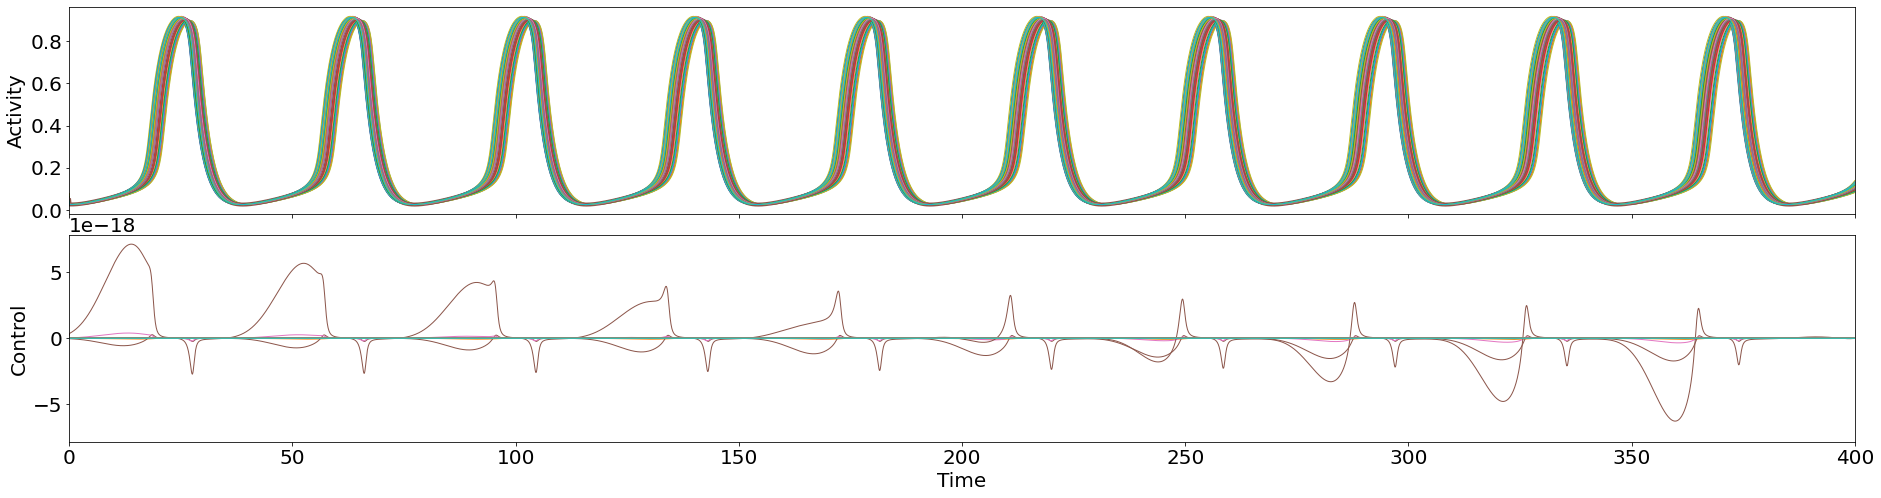

------------------------------------------------------------ wi =  10 -220.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.6534308885923671
Final cost : -0.6534308885923671
Compute control for a deterministic system
Cost in iteration 0: -0.6534308885923671
Cost in iteration 1: -0.6534308885923671
Cost in iteration 2: -0.6534308885923671
Converged in iteration 2 with cost -0.6534308885923671
Final cost : -0.6534308885923671
Compute control for a deterministic system
Cost in iteration 0: -0.6534308885923671
Cost in iteration 1: -0.6534308885923671
Converged in iteration 1 with cost -0.6534308885923671
Final cost : -0.6534308885923671
Compute control for a deterministic system
Cost in iteration 0: -0.6534308885923671
Cost in iteration 1: -0.6534308885923671
Cost in iteration 2: -0.6534308885923671
Converged in iteration 2 with cost -0.6534308885923671
Final cost : -0.6534308885923671
Compute control for a deterministic sy

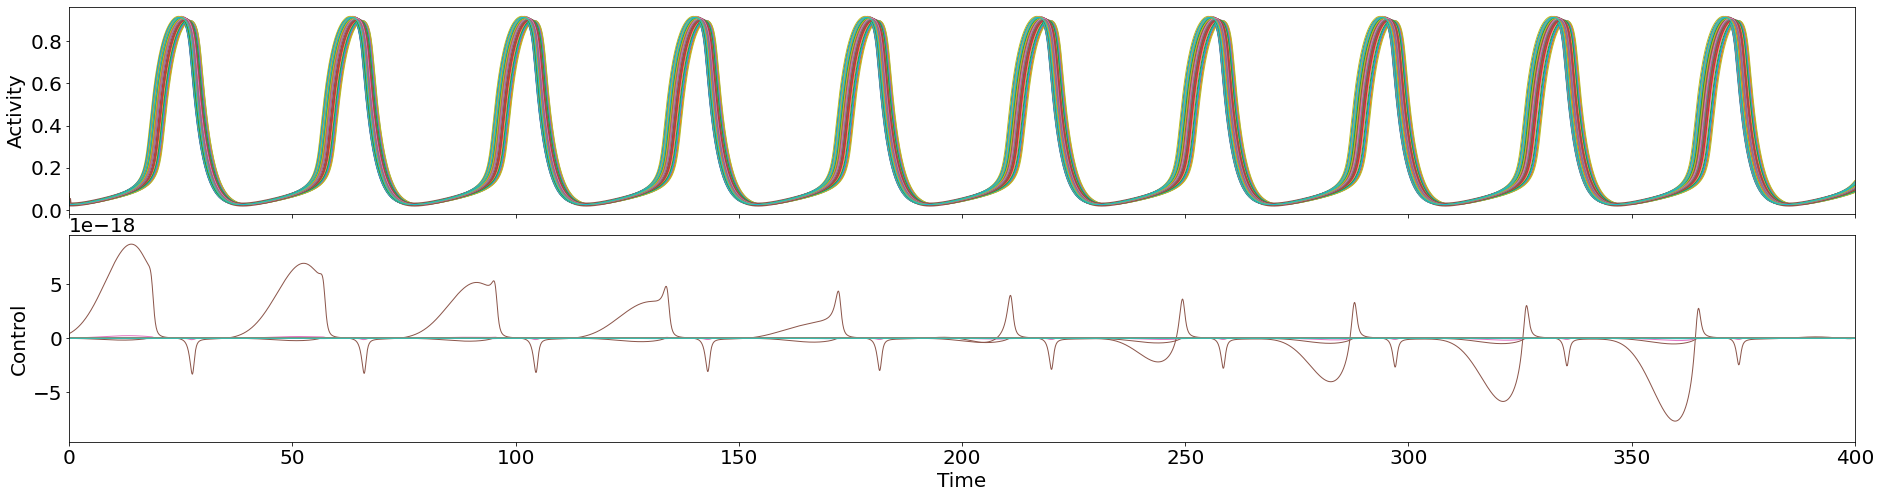

------------------------------------------------------------ wi =  12 -260.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.7722365047000711
Final cost : -0.7722365047000711
Compute control for a deterministic system
Cost in iteration 0: -0.7722365047000711
Cost in iteration 1: -0.7722365047000711
Converged in iteration 1 with cost -0.7722365047000711
Final cost : -0.7722365047000711
Compute control for a deterministic system
Cost in iteration 0: -0.7722365047000711
Cost in iteration 1: -0.7722365047000711
Converged in iteration 1 with cost -0.7722365047000711
Final cost : -0.7722365047000711
Compute control for a deterministic system
Cost in iteration 0: -0.7722365047000711
Cost in iteration 1: -0.7722365047000711
Cost in iteration 2: -0.7722365047000711
Converged in iteration 2 with cost -0.7722365047000711
Final cost : -0.7722365047000711
Compute control for a deterministic system
Cost in iteration 0: -0.772236504700

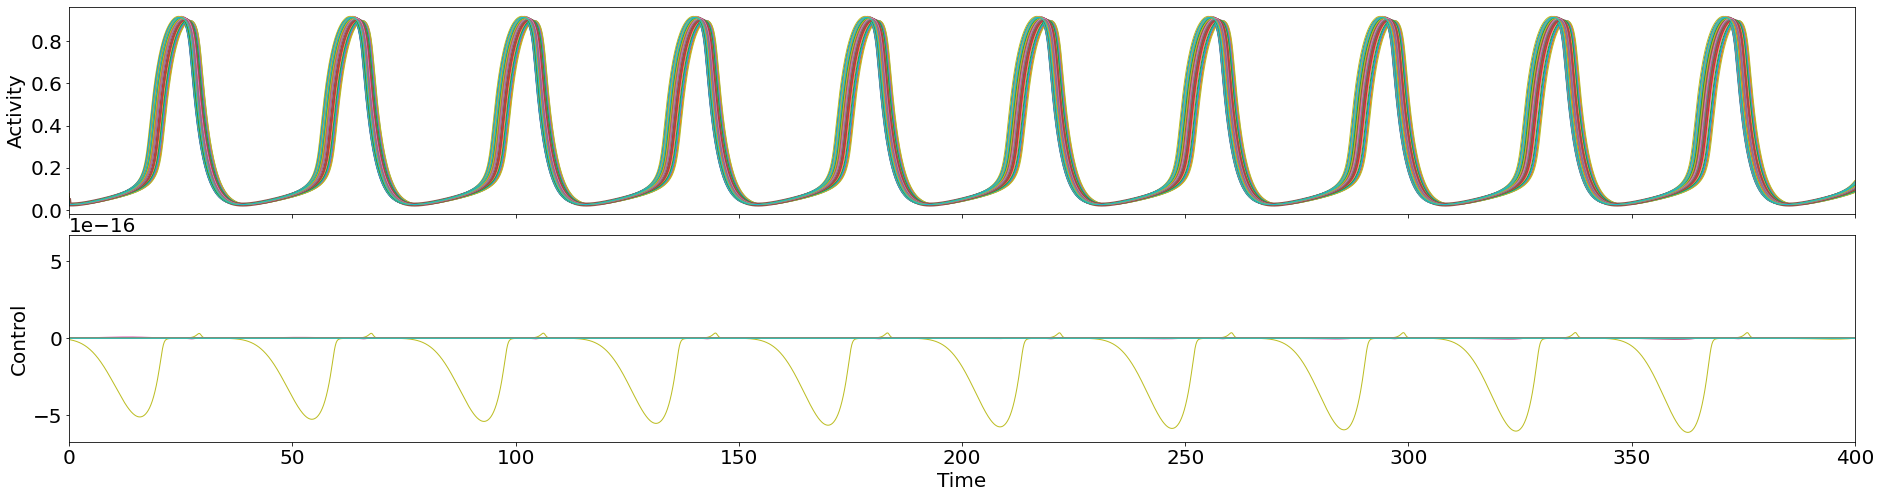

------------------------------------------------------------ wi =  14 -300.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -3.059426912612255
Final cost : -3.059426912612255
Compute control for a deterministic system
Cost in iteration 0: -3.059426912612255
Cost in iteration 1: -3.059428629237056
Cost in iteration 2: -3.059432062486327
Cost in iteration 3: -3.059438928981674
Cost in iteration 4: -3.0594526619459343
Final cost : -3.0594526619459343
Compute control for a deterministic system
Cost in iteration 0: -3.0594526619459343
Cost in iteration 1: -3.0594526619459343
Cost in iteration 2: -3.0594526619459343
Converged in iteration 2 with cost -3.0594526619459343
Final cost : -3.0594526619459343
Compute control for a deterministic system
Cost in iteration 0: -3.0594526619459343
Cost in iteration 1: -3.0594526619459343
Cost in iteration 2: -3.0594526619459343
Converged in iteration 2 with cost -3.0594526619459343
Final cos

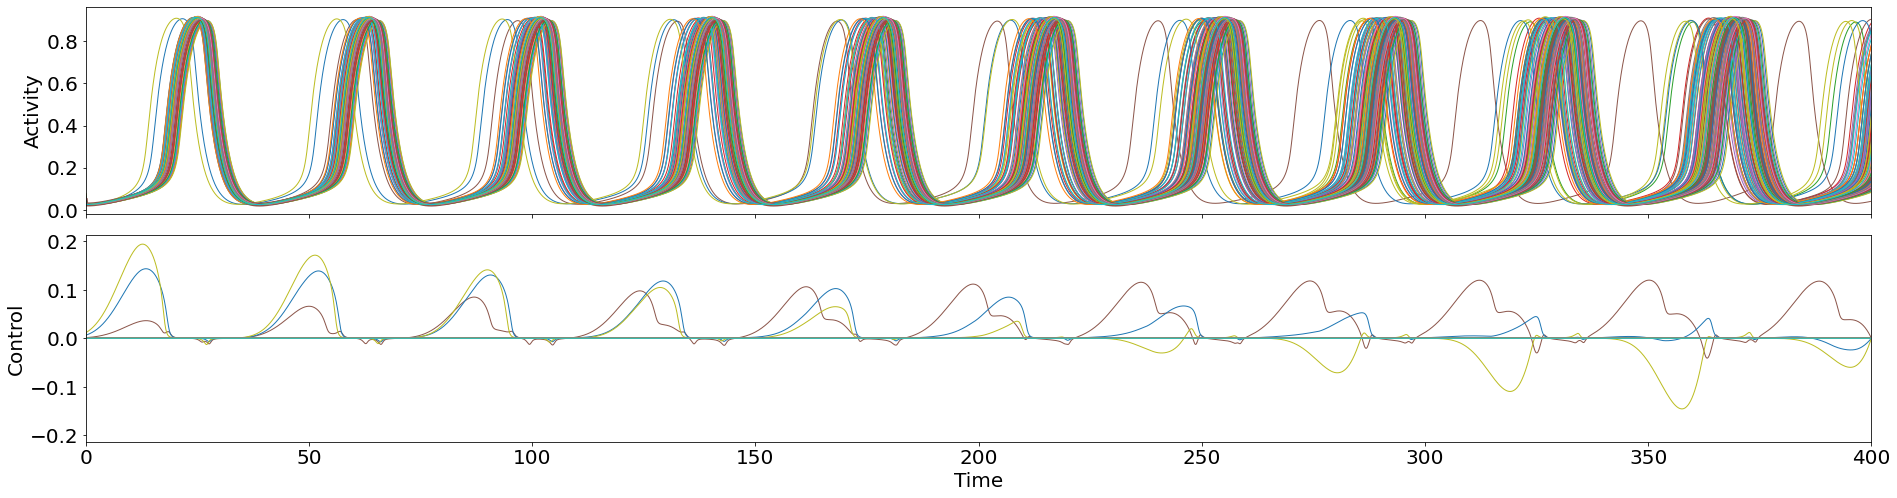

------------------------------------------------------------ wi =  16 -340.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -5.770784181933398
Final cost : -5.770784181933398
Compute control for a deterministic system
Cost in iteration 0: -5.770784181933398
Cost in iteration 1: -5.770785482964635
Cost in iteration 2: -5.770788085097088
Cost in iteration 3: -5.770793289658739
Cost in iteration 4: -5.770803700134415
Final cost : -5.770803700134415
Compute control for a deterministic system
Cost in iteration 0: -5.770803700134415
Cost in iteration 1: -5.770803700134415
Cost in iteration 2: -5.770803700134415
Converged in iteration 2 with cost -5.770803700134415
Final cost : -5.770803700134415
Compute control for a deterministic system
Cost in iteration 0: -5.770803700134415
Cost in iteration 1: -5.770803700134415
Cost in iteration 2: -5.770803700134415
Converged in iteration 2 with cost -5.770803700134415
Final cost : -5.7708

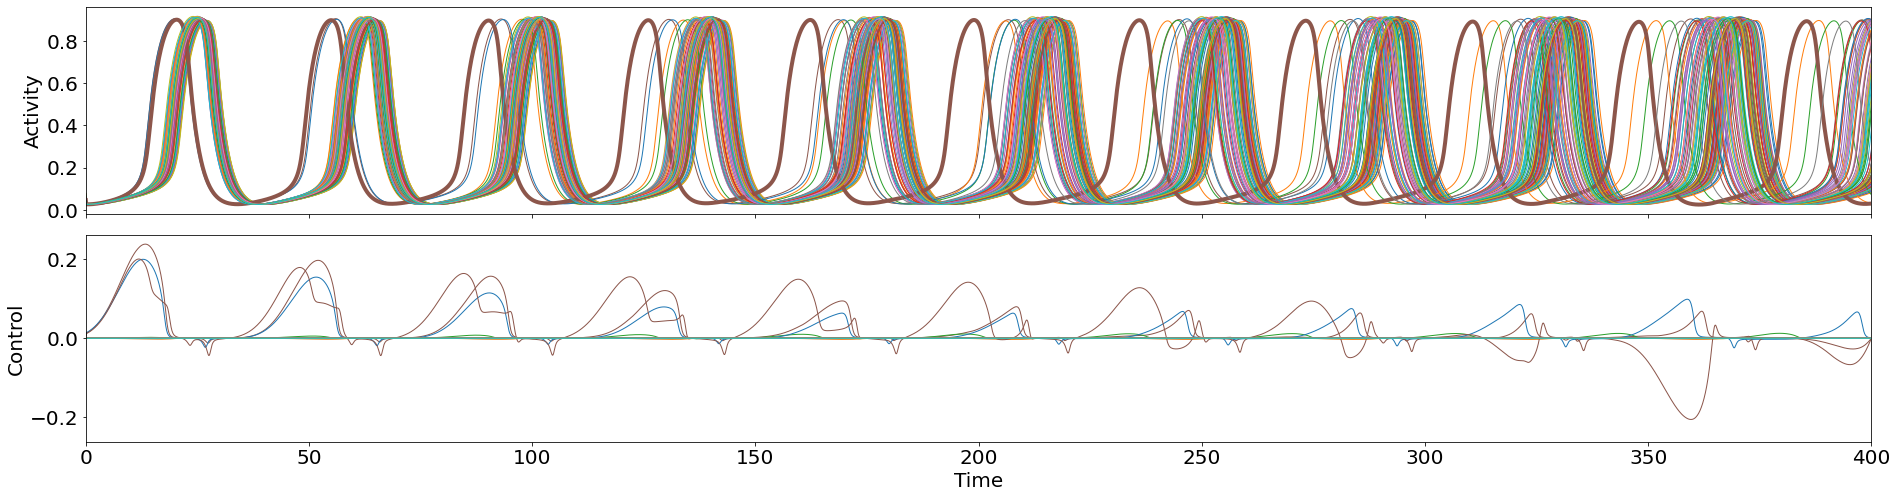

------------------------------------------------------------ wi =  18 -380.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -6.241625374952143
Final cost : -6.241625374952143
Compute control for a deterministic system
Cost in iteration 0: -6.241625374952143
Cost in iteration 1: -6.2416276323784246
Cost in iteration 2: -6.241632147241258
Cost in iteration 3: -6.241641177008027
Cost in iteration 4: -6.241659236705953
Final cost : -6.241659236705953
Compute control for a deterministic system
Cost in iteration 0: -6.241659236705953
Cost in iteration 1: -6.241659236705953
Cost in iteration 2: -6.241659236705953
Converged in iteration 2 with cost -6.241659236705953
Final cost : -6.241659236705953
Compute control for a deterministic system
Cost in iteration 0: -6.241659236705953
Cost in iteration 1: -6.241659236705953
Cost in iteration 2: -6.241659236705953
Converged in iteration 2 with cost -6.241659236705953
Final cost : -6.241

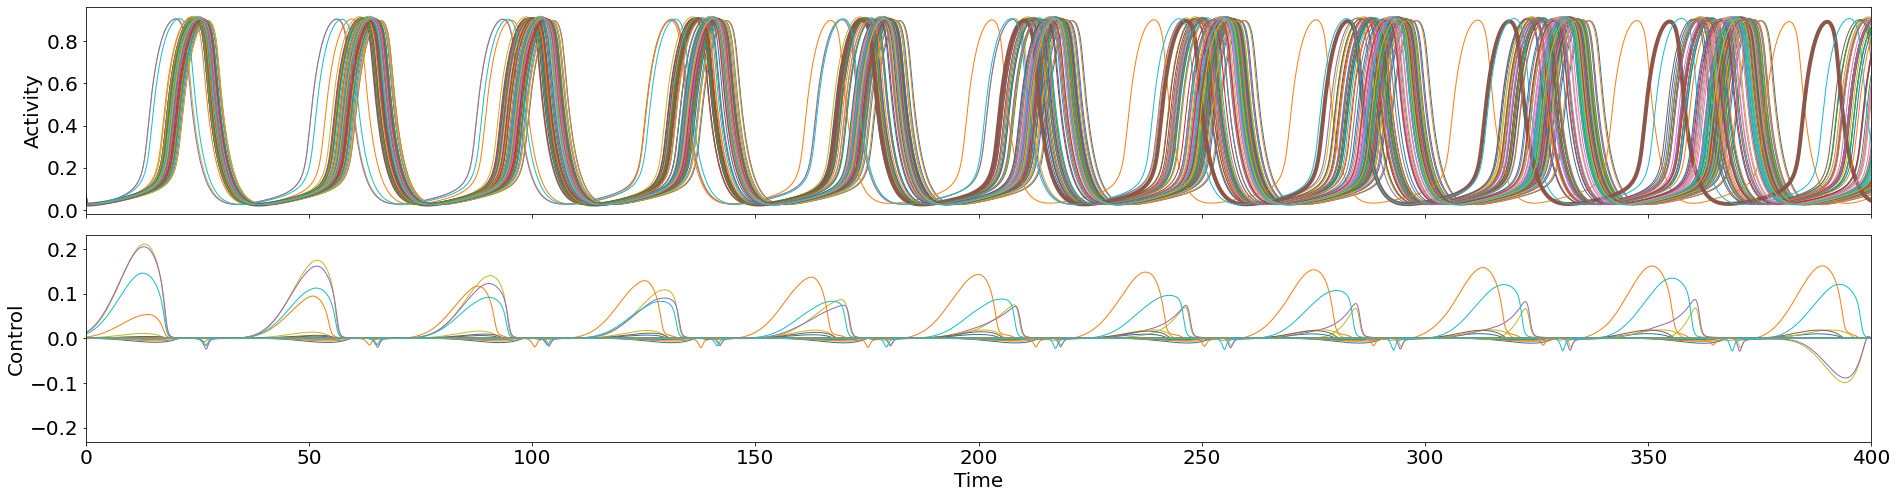

------------------------------------------------------------ wi =  20 -420.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -2.067352820246942
Final cost : -2.067352820246942
Compute control for a deterministic system
Cost in iteration 0: -2.067352820246942
Cost in iteration 1: -2.0673535422309897
Cost in iteration 2: -2.0673549862573317
Cost in iteration 3: -2.067357874542174
Cost in iteration 4: -2.0673636520344107
Final cost : -2.0673636520344107
Compute control for a deterministic system
Cost in iteration 0: -2.0673636520344107
Cost in iteration 1: -2.0673636520344107
Cost in iteration 2: -2.0673636520344107
Converged in iteration 2 with cost -2.0673636520344107
Final cost : -2.0673636520344107
Compute control for a deterministic system
Cost in iteration 0: -2.0673636520344107
Cost in iteration 1: -2.0673636520344107
Cost in iteration 2: -2.0673636520344107
Converged in iteration 2 with cost -2.0673636520344107
Final c

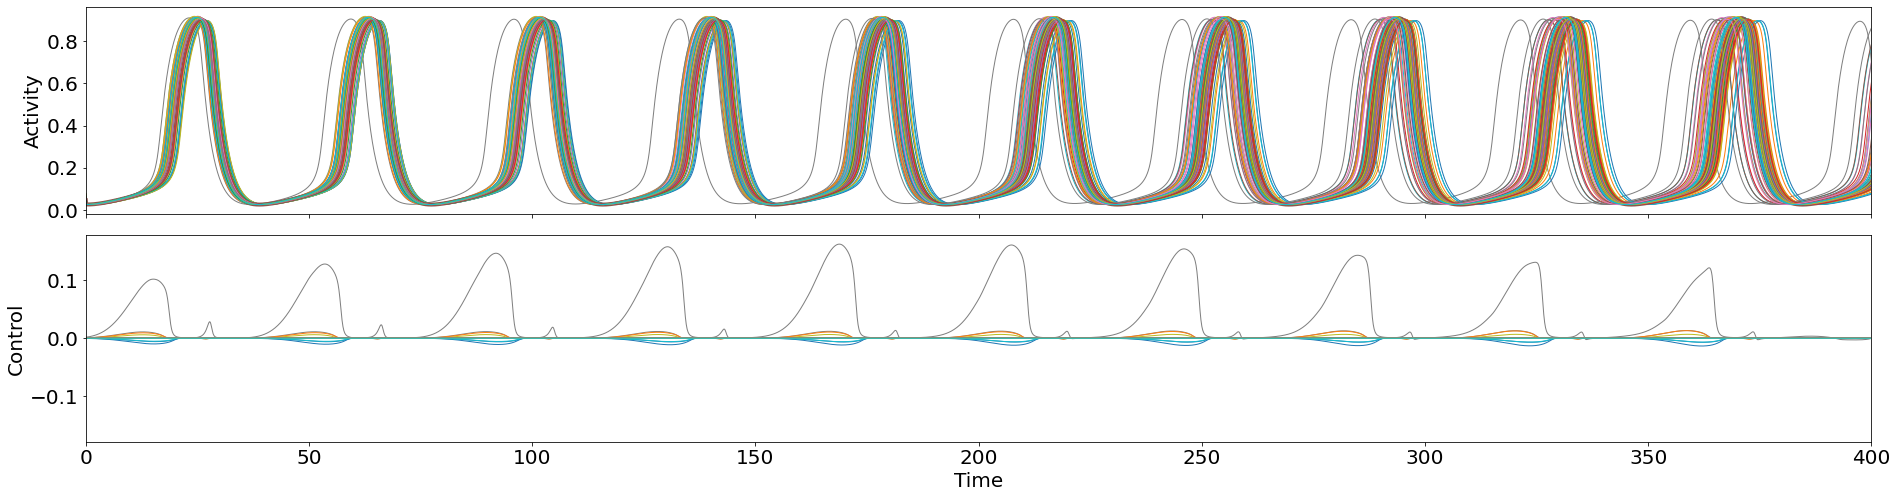

------------------------------------------------------------ wi =  22 -460.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -8.802919996259712
Final cost : -8.802919996259712
Compute control for a deterministic system
Cost in iteration 0: -8.802919996259712
Cost in iteration 1: -8.802922385222598
Cost in iteration 2: -8.802927163133146
Cost in iteration 3: -8.80293671889325
Cost in iteration 4: -8.802955830166766
Final cost : -8.802955830166766
Compute control for a deterministic system
Cost in iteration 0: -8.802955830166766


In [ ]:
it = 4
d = data_2_L1

for wi in np.arange(0,100,2):
    print("------------------------------------------------------------ wi = ", wi, d["weights"][wi])

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = d["init_state"][0]
    model.params.inh_init = d["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  d["coordinates"][0]
    model.params["inh_ext_baseline"] =  d["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_p"] = 0.
    model_controlled.weights["w_1D"] = 1.
    model_controlled.weights["w_var"] = d["weights"][wi]
    model_controlled.maximum_control_strength = max_cntrl
    
    if type(d["control"][wi]) != type(None):
        model_controlled.control = d["control"][wi].copy()
        model_controlled.update_input()

    model_controlled.channelwise_optimization = True
    model_controlled.optimize(0)

    for j in range(1):
        model_controlled.grad_method = 0
        optimize_model(model_controlled, [-6, 0, 6, -2], wi, it)
        model_controlled.grad_method = 1
        optimize_model(model_controlled, [-6, 0, 6, -2], wi, it)
    
    maxnodeind = np.argmax(np.sum(np.sum(d["control"][0]**2, axis=2), axis=1))
    print("max node ind = ", maxnodeind)
    plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, fat=[maxnodeind], filename=None, title=None)

In [19]:
print(data_0_L1["weights"])
print(data_1_L1["weights"])
print(data_2_L1["weights"]) 

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[-0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.
 -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.
 -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.
 -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.
 -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.
 -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
[  -20.   -40.   -60.   -80.  -100.  -120.  -140.  -160.  -180.  -200.
  -220.  -240.  -260.  -280.  -300.  -320.  -340.  -360.  -380.  -400.
  -420.  -440.  -460.  -480.  -500.  -520.  -540.  -560.  -580.  -600.
  -620.  -640.  -660.  -680.  -700.  -720.  -740.  -760.  -780.  -800.
  -